In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.signal import find_peaks
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import chi2_contingency

project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

sql_query = """
SELECT s.date AS order_date, s.ga_session_id AS session_id,
ac.id AS user_id, ac.is_verified, ac.is_unsubscribed,
sp.device, sp.continent, sp.country, sp.browser, sp.mobile_model_name, sp.operating_system, sp.language AS browser_language, sp.channel AS traffic_channel, sp.name AS traffic_source,
p.item_id, p.category AS product_category, p.name AS product_name, p.price, p.short_description


FROM
 `data-analytics-mate.DA.session` AS s
LEFT JOIN
`data-analytics-mate.DA.account_session` AS acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN
`data-analytics-mate.DA.account` AS ac
ON acs.account_id = ac.id
LEFT JOIN
`data-analytics-mate.DA.session_params` AS sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN
`data-analytics-mate.DA.order` AS o
ON s.ga_session_id = o.ga_session_id
LEFT JOIN
`data-analytics-mate.DA.product` AS p
ON o.item_id = p.item_id
"""
df = client.query(sql_query).to_dataframe()
df.head()

,order_date,session_id,user_id,is_verified,is_unsubscribed,device,continent,country,browser,mobile_model_name,operating_system,browser_language,traffic_channel,traffic_source,item_id,product_category,product_name,price,short_description
0,2020-11-01,5760483956,<NA>,<NA>,<NA>,desktop,Americas,United States,Chrome,Safari,Macintosh,zh,Paid Search,<Other>,99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,<NA>,<NA>,<NA>,desktop,Europe,United Kingdom,Chrome,Chrome,Web,en-us,Organic Search,(organic),99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,<NA>,<NA>,<NA>,mobile,Europe,Norway,Chrome,<Other>,Web,zh,Direct,(direct),20382932,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,<NA>,<NA>,<NA>,mobile,Africa,Nigeria,Chrome,<Other>,Android,es-es,Direct,(direct),99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,<NA>,<NA>,<NA>,desktop,Asia,China,Chrome,Chrome,Windows,en-us,Direct,(direct),99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_date         349545 non-null  dbdate 
 1   session_id         349545 non-null  Int64  
 2   user_id            27945 non-null   Int64  
 3   is_verified        27945 non-null   Int64  
 4   is_unsubscribed    27945 non-null   Int64  
 5   device             349545 non-null  object 
 6   continent          349545 non-null  object 
 7   country            349545 non-null  object 
 8   browser            349545 non-null  object 
 9   mobile_model_name  349545 non-null  object 
 10  operating_system   349545 non-null  object 
 11  browser_language   235279 non-null  object 
 12  traffic_channel    349545 non-null  object 
 13  traffic_source     349545 non-null  object 
 14  item_id            33538 non-null   Int64  
 15  product_category   33538 non-null   object 
 16  pr

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_date         349545 non-null  datetime64[ns]
 1   session_id         349545 non-null  Int64         
 2   user_id            27945 non-null   Int64         
 3   is_verified        27945 non-null   Int64         
 4   is_unsubscribed    27945 non-null   Int64         
 5   device             349545 non-null  object        
 6   continent          349545 non-null  object        
 7   country            349545 non-null  object        
 8   browser            349545 non-null  object        
 9   mobile_model_name  349545 non-null  object        
 10  operating_system   349545 non-null  object        
 11  browser_language   235279 non-null  object        
 12  traffic_channel    349545 non-null  object        
 13  traffic_source     349545 non-null  object  

In [ ]:
df["session_id"].nunique()

349545

In [ ]:
print("Start date: ", df["order_date"].min())
print("End date: ", df["order_date"].max())

Start date:  2020-11-01 00:00:00
End date:  2021-01-31 00:00:00


# **Exploratory Data Analysis**

Dataset Overview

This data frame contains **18** columns and **349,545** rows.  
Column *order_date* has to be transformed into **date** data type.  
Column *price* represents **numerical** data.  
Columns *device, continent, country, browser, mobile_model_name, operating_system, browser_language, traffic channel, traffic_source, product_category, product_name and short_description* represent **categorical** data.  
Columns *is_verified* and *is_unsubscribed* represent **boolean categorical** variables.  
There are also **identifier** columns such as *session_id*, *item_id* and *user_id*.  
In general, there are **349,545 unique session values**.
The data represents the **time period** from **2020-11-01** to **2021-01-31**.

In [ ]:
null_values = df.isna().sum()
null_values

,0
order_date,0
session_id,0
user_id,321600
is_verified,321600
is_unsubscribed,321600
device,0
continent,0
country,0
browser,0
mobile_model_name,0


In [ ]:
pct_null_values = (df.isna().sum()/len(df))*100
pct_null_values

,0
order_date,0.000000
session_id,0.000000
user_id,92.005321
is_verified,92.005321
is_unsubscribed,92.005321
device,0.000000
continent,0.000000
country,0.000000
browser,0.000000
mobile_model_name,0.000000


## Missing values

The percentage of missing values in the columns *user_id, is_verified*, and *is_unsubscribed* is about **92%**. This means that only about **8% of the rows contain information about user identification or subscription status**. One possible reason is that most **users were not authorized** or that **many events were generated by anonymous users**.  
In the column *browser_language*, about **32%** of the values are missing. This may occur for several reasons, such as **users accessing the platform via a mobile app instead of a browser, privacy settings blocking the transmission of browser information, or possible tracking limitations or errors in the data collection system.**  
It was also observed that the columns *item_id, product_category, product_name, price, and short_description* have about **90%** missing values, which indicates that information about products is available in only about **10%** of the rows. These rows likely correspond to events related to products, such as **product views, adding items to the cart, or purchases**.  
A decision was made to **keep the missing values** rather than remove or impute them, because removing these rows would eliminate a large portion of user activity data and potentially bias the analysis.

# **Analysis and visualization**

## **Users and sessions**

In [ ]:
plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (15,6)

In [ ]:
unique_sessions = df[["session_id", "order_date"]].drop_duplicates()
unique_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   session_id  349545 non-null  Int64         
 1   order_date  349545 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1)
memory usage: 5.7 MB


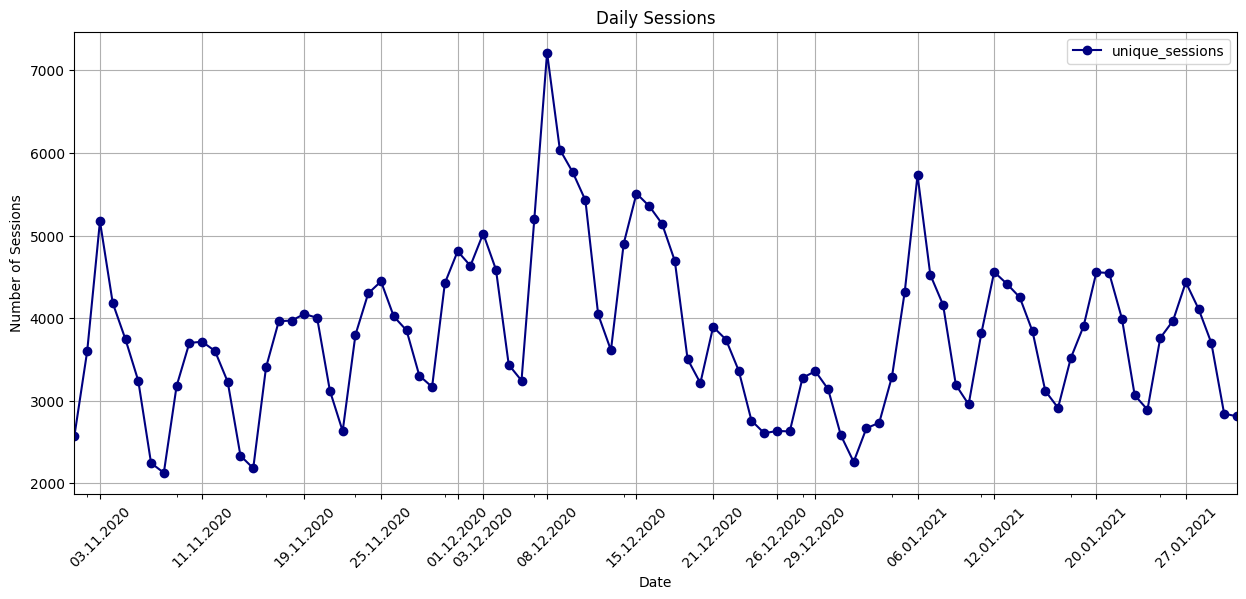

In [ ]:
sessions_per_day = (unique_sessions.groupby("order_date")["session_id"].nunique().reset_index(name="unique_sessions"))
peaks,_ = find_peaks(sessions_per_day["unique_sessions"])
peak_dates = sessions_per_day.iloc[peaks]["order_date"].tolist()
ax = sessions_per_day.plot(x ="order_date", y = "unique_sessions", color = "navy", grid = True, marker = 'o')
ax.set_xticks(peak_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.title("Daily Sessions")
plt.xticks(rotation=45)
plt.show()

The line chart above demonstrates a clear **weekly seasonality** in website traffic.

In [ ]:
df.head()

,order_date,session_id,user_id,is_verified,is_unsubscribed,device,continent,country,browser,mobile_model_name,operating_system,browser_language,traffic_channel,traffic_source,item_id,product_category,product_name,price,short_description
0,2020-11-01,5760483956,<NA>,<NA>,<NA>,desktop,Americas,United States,Chrome,Safari,Macintosh,zh,Paid Search,<Other>,99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,<NA>,<NA>,<NA>,desktop,Europe,United Kingdom,Chrome,Chrome,Web,en-us,Organic Search,(organic),99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,<NA>,<NA>,<NA>,mobile,Europe,Norway,Chrome,<Other>,Web,zh,Direct,(direct),20382932,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,<NA>,<NA>,<NA>,mobile,Africa,Nigeria,Chrome,<Other>,Android,es-es,Direct,(direct),99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,<NA>,<NA>,<NA>,desktop,Asia,China,Chrome,Chrome,Windows,en-us,Direct,(direct),99902661,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
unknown_users = (df["user_id"].isna().sum()/len(df))*100
data = {"user_type": ["Anonymous", "Subscribed"],
        "share": [unknown_users, 100- unknown_users]}
df_users = pd.DataFrame(data)
df_users

,user_type,share
0,Anonymous,92.005321
1,Subscribed,7.994679


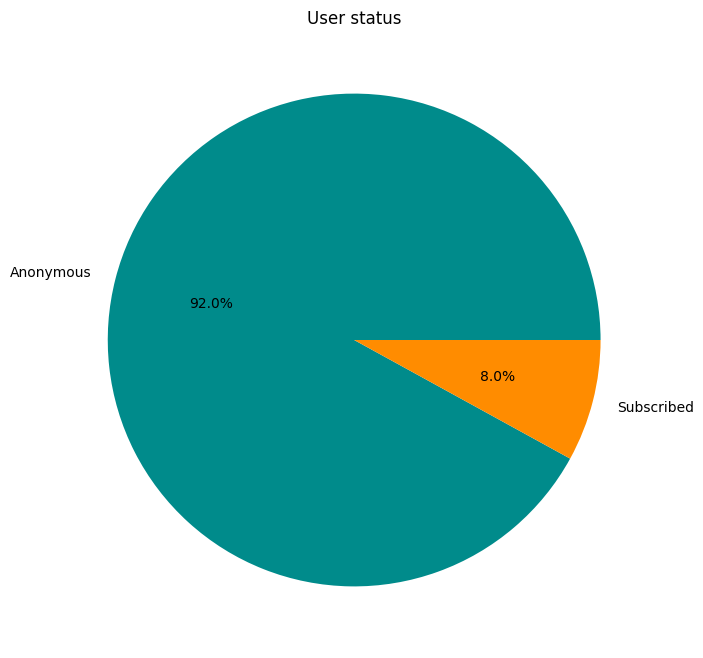

In [ ]:
colors = ["darkcyan", "darkorange"]
plt.figure(figsize= (8,8))
plt.pie(df_users["share"], labels = df_users["user_type"],colors = colors, autopct="%1.1f%%")
plt.title("User status")
plt.show()

The pie chart above shows that only **8%** of users in the dataset are subscribers, while the remaining users are anonymous. In the next step, the analysis will focus on the **subscribed users**.

In [ ]:
df_subscribed = df[df["user_id"].notna()][["order_date", "session_id","user_id"]].copy()
df_subscribed = df_subscribed.sort_values(by = "order_date")
df_subscribed

,order_date,session_id,user_id
28,2020-11-01,258365862,649280
1664,2020-11-01,2284198830,644499
1681,2020-11-01,8929203327,674700
1696,2020-11-01,2519144873,679766
1718,2020-11-01,8815083536,651659
...,...,...,...
332550,2021-01-27,3093906174,653023
332535,2021-01-27,4276599565,674772
332534,2021-01-27,4551033782,668134
332585,2021-01-27,2841290770,664842


In [ ]:
first_dates = df_subscribed.groupby("user_id")["order_date"].min().reset_index()
first_dates.rename(columns={"order_date":"first_date"}, inplace = True)
df_subscribed = df_subscribed.merge(first_dates, on = "user_id", how = "left")
df_subscribed["order_date"] = pd.to_datetime(df_subscribed["order_date"])
df_subscribed["first_date"] = pd.to_datetime(df_subscribed["first_date"])
df_subscribed["user_type"] = df_subscribed.apply(
    lambda row: "New" if row["order_date"] == row["first_date"] else "Returning", axis = 1)


In [ ]:
df_subscribed.drop_duplicates(subset="user_id")["user_type"].value_counts().reset_index()

,user_type,count
0,New,27945


As shown in the table above, the dataset includes **only unique values** in the **session_id** column. This means we **cannot analyze returning users**, as we lack data linking multiple sessions to a single individual.

## **Convertion rate**

In [ ]:
df["is_purchased"] = df["price"].notna()

In [ ]:
sessions_purchase = df.groupby("session_id").agg({
    "is_purchased": "max",
    "user_id": "first",
    "traffic_channel": "first",
    "country": "first",
    "device": "first"
}).reset_index()
sessions_purchase

,session_id,is_purchased,user_id,traffic_channel,country,device
0,1205,False,<NA>,Paid Search,United States,desktop
1,6412,False,<NA>,Direct,Turkey,tablet
2,17626,False,<NA>,Organic Search,Canada,desktop
3,24095,False,<NA>,Organic Search,India,mobile
4,54555,False,<NA>,Organic Search,United States,desktop
...,...,...,...,...,...,...
349540,9999783761,False,637693,Organic Search,Spain,desktop
349541,9999855257,False,<NA>,Social Search,Turkey,mobile
349542,9999964001,False,<NA>,Paid Search,United States,desktop
349543,9999993392,False,<NA>,Undefined,Sweden,mobile


In [ ]:
total_sessions = sessions_purchase["session_id"].nunique()
sessions_with_purchase = sessions_purchase["is_purchased"].sum()
convertion_rate = sessions_with_purchase/total_sessions*100
print(convertion_rate)

9.594758900856828


The **conversion rate** of **9.59%** indicates that a relatively small portion of sessions lead to a purchase. Considering that this is a furniture store, where purchases are typically expensive and decision-making takes longer, this is actually a relatively high conversion rate for this type of business.

In [ ]:
df["is_authorized"] = df["user_id"].notna()
auth_analysis = df.groupby(["is_authorized", "is_purchased"]) ["user_id"].size().unstack(fill_value = 0)
auth_analysis

is_purchased,False,True
is_authorized,,
False,290843,30757
True,25164,2781


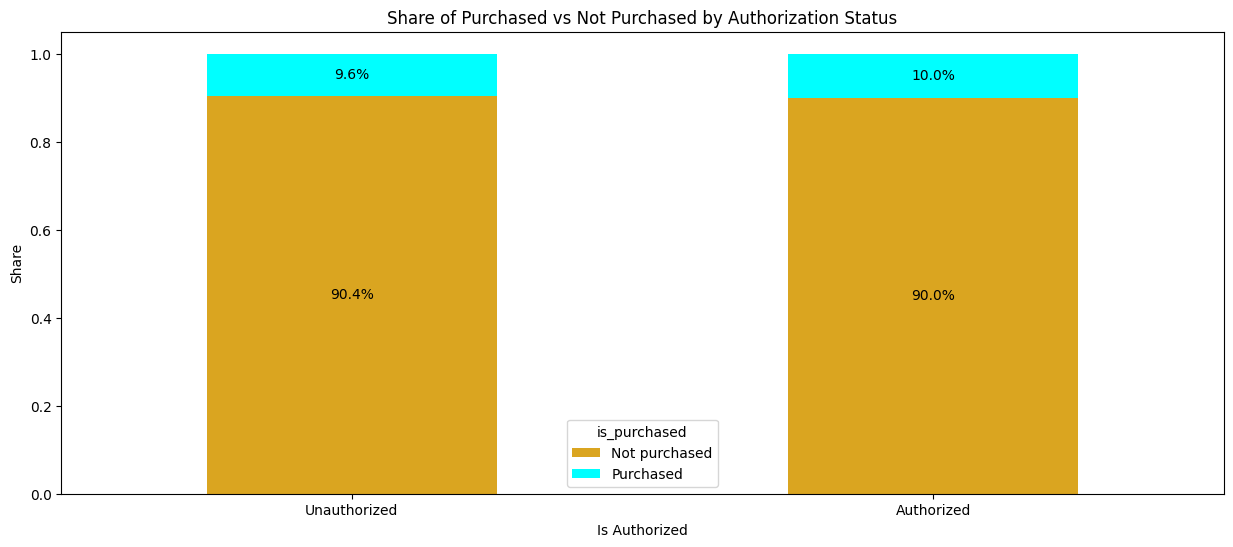

In [ ]:
auth_share = auth_analysis.div(auth_analysis.sum(axis = 1), axis = 0)
auth_share = auth_share.rename(index = {False: "Unauthorized", True: "Authorized"})
auth_share = auth_share.rename(columns = {False: "Not purchased", True: "Purchased"})
colors = ["goldenrod", "aqua"]
ax = auth_share.plot(kind = "bar", stacked = True,color = colors)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1%}",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )
plt.title("Share of Purchased vs Not Purchased by Authorization Status")
plt.xlabel("Is Authorized")
plt.ylabel("Share")
plt.xticks(rotation=0)
plt.show()

The bar chart shows the users conversion rate, comparing authorized and unauthorized customers. The results are very similar: approximately **9.6%** of **unauthorized** users made a purchase, while about **10%** of **authorized** users also completed a purchase on the website. It means that authorization status has almost **no impact** on **convertion rate**. This suggests that users are equally likely to complete a purchase regardless of whether they are logged in, and that other factors may play a more important role in driving conversions.

In [ ]:
channel_analysis = sessions_purchase.groupby("traffic_channel").agg(sessions = ("session_id", "count"),purchases = ("is_purchased", "sum"))
channel_analysis["channel_convertion"] = channel_analysis["purchases"]/channel_analysis["sessions"]*100
channel_analysis.sort_values("channel_convertion", ascending = False)
channel_analysis

,sessions,purchases,channel_convertion
traffic_channel,,,
Direct,81382,7800,9.584429
Organic Search,124425,11921,9.580872
Paid Search,94341,9042,9.58438
Social Search,27914,2716,9.729885
Undefined,21483,2059,9.584322


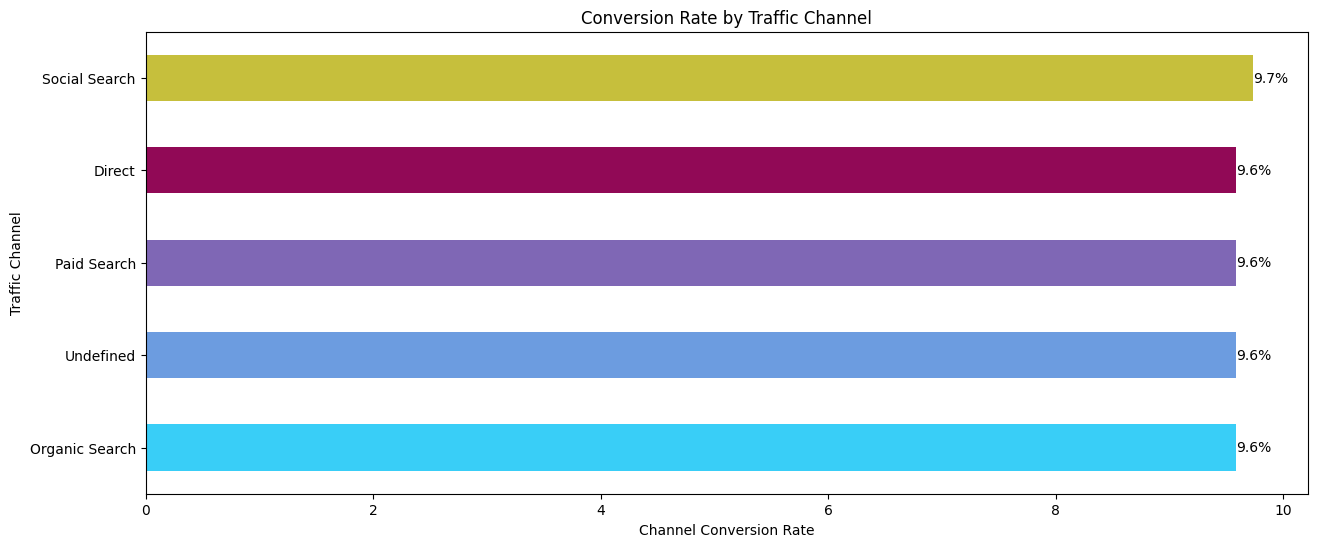

In [ ]:
colors = ["#39CEF7", "#6C9CE0", "#7F67B5", "#910956", "#C6BF3C"]
ax = channel_analysis["channel_convertion"].sort_values().plot(kind = "barh", color = colors)
for bar in ax.patches:
  width = bar.get_width()
  ax.text(
      width,
      bar.get_y()+bar.get_height()/2,
      f"{width:.1f}%",
      va = "center",
      ha = "left"
  )

plt.title("Conversion Rate by Traffic Channel")
plt.xlabel("Channel Conversion Rate")
plt.ylabel("Traffic Channel")

plt.show()

Conversion rates are highly **consistent** across traffic channels, suggesting that user acquisition source has minimal impact on purchase likelihood. **Social Search** shows a slightly **higher** **conversion**, but the difference is marginal and may not be statistically significant

In [ ]:
country_analysis = sessions_purchase.groupby("country").agg(sessions = ("session_id", "count"),purchases = ("is_purchased", "sum"))
country_analysis["country_convertion"] = country_analysis["purchases"]/country_analysis["sessions"]*100
country_analysis.sort_values("country_convertion", ascending = False, inplace = True)
country_analysis

,sessions,purchases,country_convertion
country,,,
Trinidad & Tobago,68,12,17.647059
Jamaica,106,18,16.981132
Malta,69,11,15.942029
Georgia,154,22,14.285714
Paraguay,70,9,12.857143
...,...,...,...
Bolivia,87,6,6.896552
Bosnia & Herzegovina,78,5,6.410256
Guatemala,136,7,5.147059


In [ ]:
top_5_countries_convertion = country_analysis.head(5)
top_5_countries_convertion

,sessions,purchases,country_convertion
country,,,
Trinidad & Tobago,68,12,17.647059
Jamaica,106,18,16.981132
Malta,69,11,15.942029
Georgia,154,22,14.285714
Paraguay,70,9,12.857143


The initial **ranking of countries** by conversion rate appears to **be biased** by **small sample sizes**. Several countries in the top positions have relatively low numbers of sessions and purchases, which **makes** the raw conversion **metric unstable**.
To address this issue, we will apply **Bayesian smoothing** to obtain more reliable and statistically robust estimates of conversion rates.

In [ ]:
country_analysis["sessions"].describe()

,sessions
count,108.0
mean,3236.527778
std,15203.197562
min,66.0
25%,142.75
50%,474.5
75%,1724.5
max,153470.0


In [ ]:
global_rate = country_analysis["purchases"].sum() / country_analysis["sessions"].sum()

alpha = 475 # median = 474.5

country_analysis["smoothed_conversion"] = (
    country_analysis["purchases"] + alpha * global_rate
) / (country_analysis["sessions"] + alpha)*100
top_5_countries_smoothed_convertion = country_analysis.sort_values("smoothed_conversion", ascending = False).head(5).reset_index()[["country", "smoothed_conversion"]]
top_5_countries_smoothed_convertion

,country,smoothed_conversion
0,Pakistan,11.473019
1,Finland,11.123797
2,Jamaica,10.942359
3,Georgia,10.74326
4,Trinidad & Tobago,10.60315


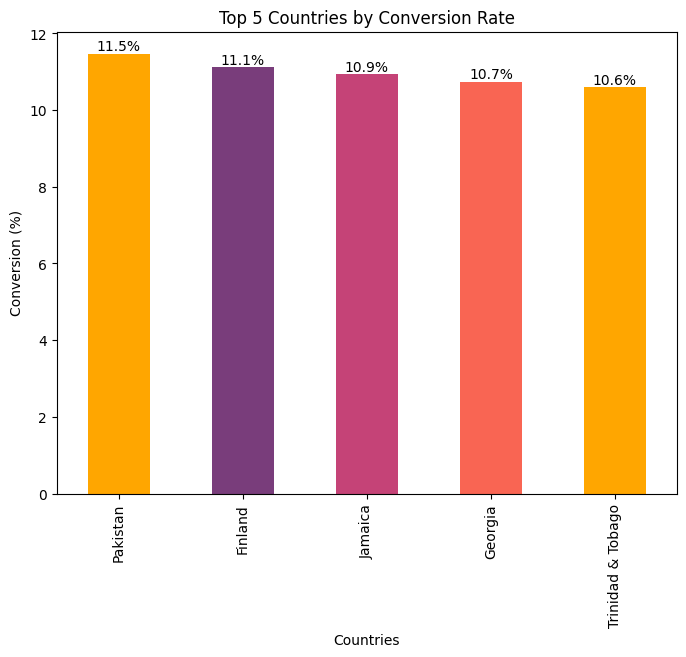

In [ ]:
df_countries = top_5_countries_smoothed_convertion.set_index("country")
colors = ["#ffa600", "#793d7b", "#c54377", "#f96553", "#ffa600"]
ax = df_countries["smoothed_conversion"].sort_values(ascending=False).plot(kind = "bar", color = colors, figsize = (8,6))
for bar in ax.patches:
  height = bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height,
      f"{height:.1f}%",
      va = "bottom",
      ha = "center"
  )

plt.title("Top 5 Countries by Conversion Rate")
plt.xlabel("Countries")
plt.ylabel("Conversion (%)")

plt.show()

While **Pakistan** has **the highest** observed conversion rate, the **gap** between the top countries is relatively **narrow** (approximately 0.9 percentage points between the highest and lowest). This indicates that the differences may not be practically significant.

Further **statistical testing** is required to determine whether these differences reflect true performance variations or are driven by random fluctuations.

In [ ]:
contingency_table = country_analysis[["purchases"]].copy()
contingency_table["no_purchases"] = country_analysis["sessions"] - country_analysis["purchases"]
contingency_table["purchases"] = contingency_table["purchases"].astype(int)
contingency_table["no_purchases"] = contingency_table["no_purchases"].astype(int)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(p)
print(expected.min())


0.22720816747646658
6.332540874565507


The chi-square test **did not** show a **statistically significant association** between country and purchase outcome, suggesting that the observed **conversion differences** may be due to **random variation**.

In [ ]:
pivot_convertion = sessions_purchase.groupby(["traffic_channel", "device"]).agg(sessions = ("session_id", "nunique"), purchases = ("is_purchased", "sum")).reset_index()
pivot_convertion["convertion"] = pivot_convertion["purchases"]/pivot_convertion["sessions"]*100
pivot_convertion

,traffic_channel,device,sessions,purchases,convertion
0,Direct,desktop,47825,4655,9.733403
1,Direct,mobile,31745,2985,9.403056
2,Direct,tablet,1812,160,8.830022
3,Organic Search,desktop,72622,7011,9.654099
4,Organic Search,mobile,49014,4655,9.497286
5,Organic Search,tablet,2789,255,9.143062
6,Paid Search,desktop,55167,5261,9.536498
7,Paid Search,mobile,37034,3574,9.650591
8,Paid Search,tablet,2140,207,9.672897
9,Social Search,desktop,16288,1594,9.786346


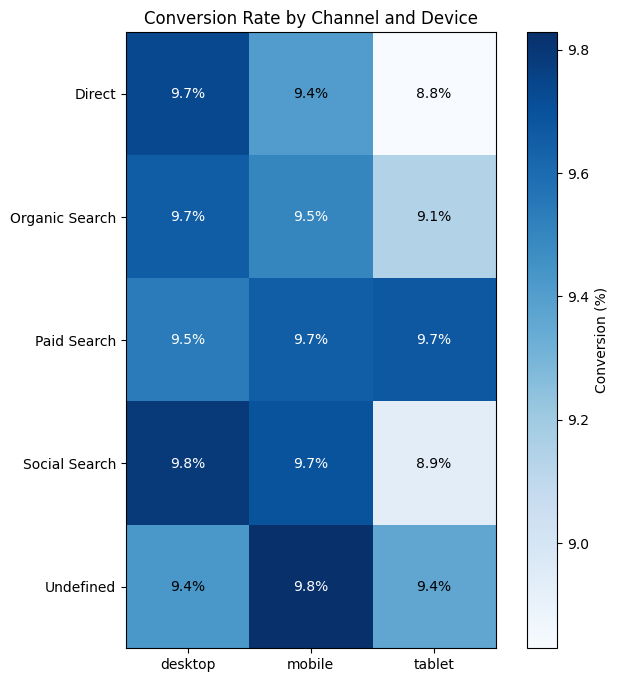

In [ ]:
heatmap_data = pivot_convertion.pivot(
    index="traffic_channel",
    columns="device",
    values="convertion"
)
plt.figure(figsize= (8,8))
plt.imshow(heatmap_data, cmap="Blues")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if value > heatmap_data.values.mean():
            text_color = "white"
        else:
            text_color = "black"
        plt.text(j, i, f"{value:.1f}%", ha="center", va="center", color= text_color)

plt.colorbar(label="Conversion (%)")
plt.title("Conversion Rate by Channel and Device")

plt.show()

The relatively **small differences** in conversion rates across channels and devices suggest that **performance** is fairly **stable** across segments. This indicates that **optimization** efforts may be better **focused** **on other** **factors**, such as user behavior or traffic quality, rather than device-specific improvements.

# **Key Findings**

* The data demonstrate a clear weekly seasonality in website traffic.
* Only 8% of users in the dataset are subscribers.
* The authorization status has almost no impact on convertion rate.
* Conversion rates are stable across channels and devices.
* Device type does not significantly impact conversion.
* Country differences are not statistically significant.
* Tablet shows slightly lower performance.

# **Recommendations**

* Align marketing campaigns and promotional activities with peak traffic periods to maximize impact. During low-traffic days, consider running targeted campaigns or incentives to stabilize demand.
* Increase efforts to convert anonymous users into subscribers, as a larger identified user base enables better personalization and retention strategies.
* Since subscription does not currently improve conversion, it is important to evaluate the value proposition of being a subscriber and consider introducing incentives
* Avoid focusing optimization efforts on specific channels or devices, as performance is consistent across segments. Instead, prioritize improvements in the overall conversion funnel.
* Geographic segmentation does not currently require tailored strategies, allowing for a unified approach across markets.
* Although differences are small, tablet performance should be reviewed to identify potential UX or technical issues.